Device: cpu

── Label distribution ──────────────────
  NORMAL (0): 1864  (84.3%)
  SPIKE  (1):   57  (2.6%)
  CRASH  (2):  104  (4.7%)
  BUBBLE (3):  187  (8.5%)

── Splits ──────────────────────────────
  Train 1769  2017-06-19 → 2024-07-02
  Val    221  2024-07-03 → 2025-05-19
  Test   222  2025-05-20 → 2026-04-07

── Window tensors ──────────────────────
  Train: X=(1739, 30, 13)  y=(1739,)
  Val  : X=(191, 30, 13)  y=(191,)
  Test : X=(192, 30, 13)  y=(192,)

── [1/3] Training Transformer ──────────
  Transformer class weights: {'NORMAL': 0.3, 'SPIKE': 20.22, 'CRASH': 9.99, 'BUBBLE': 2.56}
  Ep 1/25  tr_loss=1.7631 tr_acc=0.108  va_loss=2.1677 va_acc=0.016  ✓
  Ep 2/25  tr_loss=1.5700 tr_acc=0.133  va_loss=2.1385 va_acc=0.162  ✓
  Ep 3/25  tr_loss=1.4661 tr_acc=0.221  va_loss=2.5216 va_acc=0.031
  Ep 4/25  tr_loss=1.4345 tr_acc=0.212  va_loss=2.4699 va_acc=0.042
  Ep 5/25  tr_loss=1.3566 tr_acc=0.260  va_loss=2.2455 va_acc=0.162
  Ep 6/25  tr_loss=1.3682 tr_acc=0.259  va_loss=2.51

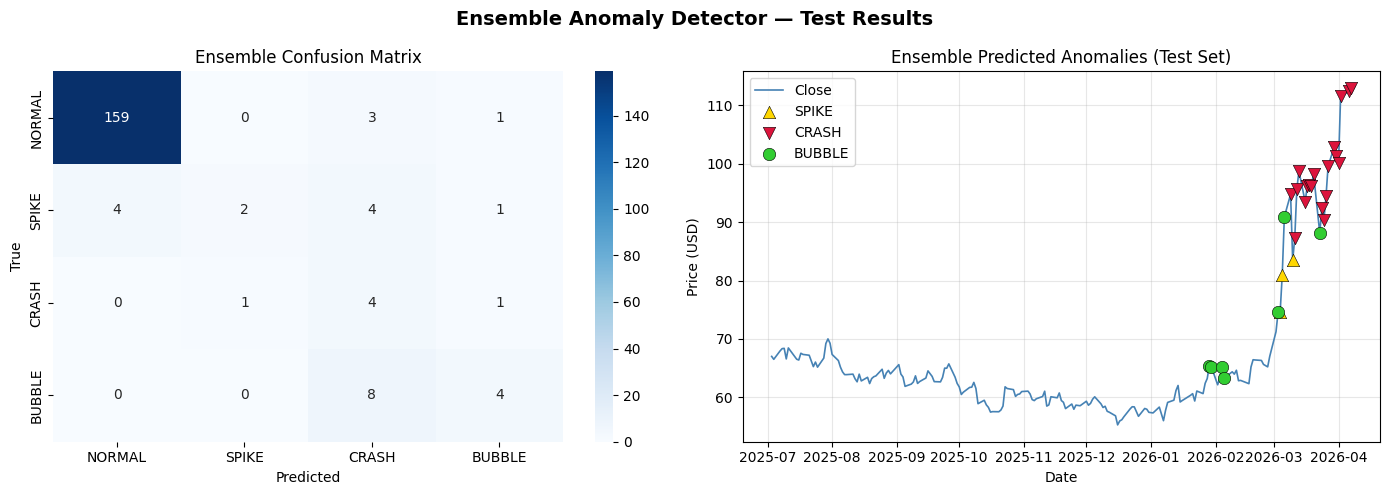

  Plot saved → ensemble_results.png

── Sample Predictions ──────────────────

  ┌─ 2025-07-03  [true: NORMAL]
  │  Ensemble Verdict : ✅ NORMAL  (99.5%)
  │  ────────────────────────────────────────
  │  Transformer : SPIKE   (39.9%)
  │  XGBoost     : NORMAL  (82.6%)
  │  ISO score   : 0.460  (normal)
  │  ────────────────────────────────────────
  │  NORMAL :  99.5%  ███████████████████████
  │  SPIKE  :   0.4%  
  │  CRASH  :   0.1%  
  │  BUBBLE :   0.1%  
  └──────────────────────────────────────────────

  ┌─ 2025-09-10  [true: NORMAL]
  │  Ensemble Verdict : ✅ NORMAL  (100.0%)
  │  ────────────────────────────────────────
  │  Transformer : NORMAL  (38.6%)
  │  XGBoost     : NORMAL  (100.0%)
  │  ISO score   : 0.370  (normal)
  │  ────────────────────────────────────────
  │  NORMAL : 100.0%  ███████████████████████
  │  SPIKE  :   0.0%  
  │  CRASH  :   0.0%  
  │  BUBBLE :   0.0%  
  └──────────────────────────────────────────────

  ┌─ 2025-11-17  [true: NORMAL]
  │  Ensemble

In [11]:
"""
Ensemble Market Anomaly Detection Pipeline
============================================
Strategy:
  - Transformer  → best at NORMAL & BUBBLE (sequence context)
  - XGBoost      → best at SPIKE & CRASH   (sharp statistical features)
  - Isolation Forest → unsupervised anomaly score (extra signal for rare events)
  - Meta-Classifier (Logistic Regression) → combines all three

Why this works for SPIKE/CRASH:
  Spikes/crashes are single-day outliers — raw statistical features
  (z-score, ATR, volume shock) carry more signal than 30-day sequences.
  XGBoost + IsolationForest captures that directly.

Split: 80% train | 10% val | 10% test
"""

import os, math, warnings
import numpy as np
import pandas as pd
import matplotlib
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import xgboost as xgb

warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)

# ──────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────
WINDOW    = 30
EPOCHS    = 25
BATCH     = 64
LR        = 3e-4
PATIENCE  = 6
DEVICE    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LABEL_MAP = {0:"NORMAL", 1:"SPIKE", 2:"CRASH", 3:"BUBBLE"}

# Transformer sequence features
SEQ_FEAT = [
    "Return","LogReturn","Range",
    "MA5_ratio","MA20_ratio","MA50_ratio",
    "Volatility5","Volatility20","RSI","MACD",
    "VolumeRatio","Momentum5","Momentum20"
]

# XGBoost point features — engineered for sharp single-day moves
XGB_FEAT = [
    "Return","LogReturn","Range","RSI","MACD",
    "VolumeRatio","Momentum5","Momentum20",
    "ZScore5","ZScore20",          # how many σ from rolling mean
    "ATR14",                        # Average True Range
    "VolumeSurge",                  # volume vs 5-day avg
    "PriceAccel",                   # second derivative of price
    "GapOpen",                      # overnight gap
    "UpperShadow","LowerShadow",    # candlestick shadows
]

print(f"Device: {DEVICE}\n")

# ──────────────────────────────────────────────────────
# 1. FEATURE ENGINEERING
# ──────────────────────────────────────────────────────
def engineer(path):
    df = pd.read_csv(path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
    c  = df["Close"]; h = df["High"]; l = df["Low"]; o = df["Open"]

    # Base features
    df["Return"]       = c.pct_change()
    df["LogReturn"]    = np.log(c / c.shift(1))
    df["Range"]        = (h - l) / c
    df["MA5"]          = c.rolling(5).mean()
    df["MA20"]         = c.rolling(20).mean()
    df["MA50"]         = c.rolling(50).mean()
    df["MA5_ratio"]    = c / df["MA5"]
    df["MA20_ratio"]   = c / df["MA20"]
    df["MA50_ratio"]   = c / df["MA50"]
    df["Volatility5"]  = df["Return"].rolling(5).std()
    df["Volatility20"] = df["Return"].rolling(20).std()
    d = c.diff()
    g = d.clip(lower=0).rolling(14).mean()
    ls = (-d.clip(upper=0)).rolling(14).mean()
    df["RSI"]          = 100 - 100 / (1 + g / (ls + 1e-9))
    df["MACD"]         = c.ewm(span=12).mean() - c.ewm(span=26).mean()
    df["VolumeRatio"]  = df["Volume"] / df["Volume"].rolling(20).mean()
    df["Momentum5"]    = c / c.shift(5)  - 1
    df["Momentum20"]   = c / c.shift(20) - 1

    # Extra spike/crash features
    roll5_mean         = df["Return"].rolling(5).mean()
    roll5_std          = df["Return"].rolling(5).std()
    roll20_mean        = df["Return"].rolling(20).mean()
    roll20_std         = df["Return"].rolling(20).std()
    df["ZScore5"]      = (df["Return"] - roll5_mean)  / (roll5_std  + 1e-9)
    df["ZScore20"]     = (df["Return"] - roll20_mean) / (roll20_std + 1e-9)

    # ATR14
    tr                 = pd.concat([h-l, (h-c.shift()).abs(), (l-c.shift()).abs()], axis=1).max(axis=1)
    df["ATR14"]        = tr.rolling(14).mean() / c

    df["VolumeSurge"]  = df["Volume"] / (df["Volume"].rolling(5).mean() + 1e-9)
    df["PriceAccel"]   = df["Return"] - df["Return"].shift(1)
    df["GapOpen"]      = (o - c.shift()) / (c.shift() + 1e-9)
    df["UpperShadow"]  = (h - pd.concat([c, o], axis=1).max(axis=1)) / (c + 1e-9)
    df["LowerShadow"]  = (pd.concat([c, o], axis=1).min(axis=1) - l)  / (c + 1e-9)

    return df.dropna().reset_index(drop=True)

# ──────────────────────────────────────────────────────
# 2. ANOMALY LABELLING
# ──────────────────────────────────────────────────────
def label(df, horizon=3):
    """
    SPIKE/CRASH : will it happen within next `horizon` days?
    BUBBLE      : is it happening RIGHT NOW (current day)?
    Priority    : CRASH > SPIKE > BUBBLE > NORMAL
    """
    ret   = df["Return"]
    sigma = ret.std()
    n     = len(df)
    y     = np.zeros(n, dtype=int)

    for i in range(n - horizon):
        future_returns = ret.iloc[i+1 : i+horizon+1]
        curr_ratio     = df["MA50_ratio"].iloc[i]
        curr_mom       = df["Momentum20"].iloc[i]

        # BUBBLE — current day condition (same as before)
        if curr_ratio > 1.10 and curr_mom > 0.10:
            y[i] = 3

        # SPIKE/CRASH — forward-looking over next `horizon` days
        if future_returns.max() > 2 * sigma:
            y[i] = 1   # SPIKE coming, overwrites BUBBLE if overlap
        if future_returns.min() < -2 * sigma:
            y[i] = 2   # CRASH coming, highest priority

    df = df.copy(); df["Label"] = y
    print("── Label distribution ──────────────────")
    for k, v in LABEL_MAP.items():
        n_ = (y == k).sum()
        print(f"  {v:7s}({k}): {n_:4d}  ({100*n_/len(y):.1f}%)")
    return df
# ──────────────────────────────────────────────────────
# 3. SLIDING WINDOW DATASET  (for Transformer)
# ──────────────────────────────────────────────────────
class WindowDS(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]

def make_windows(df, scaler=None, fit=False):
    v = df[SEQ_FEAT].values.astype(np.float32)
    if fit: scaler = StandardScaler(); v = scaler.fit_transform(v)
    else:   v = scaler.transform(v)
    X, y = [], []
    for i in range(WINDOW, len(df)):
        X.append(v[i-WINDOW:i])          # window ends at T (no change)
        y.append(int(df["Label"].iloc[i]))  # label already looks 3 days ahead for spike/crash
    return np.array(X), np.array(y, dtype=np.int64), scaler
# ──────────────────────────────────────────────────────
# 4. TRANSFORMER MODEL  (unchanged — good at NORMAL/BUBBLE)
# ──────────────────────────────────────────────────────
class PosEnc(nn.Module):
    def __init__(self, d, maxlen=512, p=0.1):
        super().__init__()
        self.drop = nn.Dropout(p)
        pe  = torch.zeros(maxlen, d)
        pos = torch.arange(maxlen).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d, 2).float() * (-math.log(10000) / d))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x): return self.drop(x + self.pe[:, :x.size(1)])

class AnomalyTransformer(nn.Module):
    def __init__(self, in_dim, seq_len, d=128, heads=4, layers=3, ff=256, drop=0.2, nc=4):
        super().__init__()
        self.proj = nn.Linear(in_dim, d)
        self.cls  = nn.Parameter(torch.zeros(1, 1, d))
        self.pos  = PosEnc(d, seq_len+1, drop)
        enc_layer = nn.TransformerEncoderLayer(d, heads, ff, drop,
                      activation="gelu", batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc_layer, layers, enable_nested_tensor=False)
        self.head = nn.Sequential(
            nn.LayerNorm(d), nn.Dropout(drop),
            nn.Linear(d, 64), nn.GELU(), nn.Linear(64, nc))
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                if m.bias is not None: nn.init.zeros_(m.bias)
        nn.init.trunc_normal_(self.cls, std=0.02)

    def forward(self, x):
        B = x.size(0)
        h = self.proj(x)
        h = torch.cat([self.cls.expand(B, -1, -1), h], dim=1)
        h = self.pos(h); h = self.enc(h)
        return self.head(h[:, 0])

# ──────────────────────────────────────────────────────
# 5. TRAIN / EVAL HELPERS
# ──────────────────────────────────────────────────────
def train_epoch(model, loader, opt, crit):
    model.train(); tl = tc = tn = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        opt.zero_grad(); lo = model(xb); ls = crit(lo, yb)
        ls.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.); opt.step()
        tl += ls.item()*xb.size(0); tc += (lo.argmax(1)==yb).sum().item(); tn += xb.size(0)
    return tl/tn, tc/tn

@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval(); tl = tc = tn = 0; AP, AL, AB = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lo = model(xb); ls = crit(lo, yb); pr = torch.softmax(lo, -1)
        tl += ls.item()*xb.size(0); tc += (lo.argmax(1)==yb).sum().item(); tn += xb.size(0)
        AP.extend(lo.argmax(1).cpu().detach().tolist())
        AL.extend(yb.cpu().tolist())
        AB.extend(pr.cpu().detach().tolist())
    return (tl/tn, tc/tn,
            np.array(AP, dtype=np.int64),
            np.array(AL, dtype=np.int64),
            np.array(AB, dtype=np.float32))

# ──────────────────────────────────────────────────────
# 6. TRAIN TRANSFORMER
# ──────────────────────────────────────────────────────
def train_transformer(Xtr, ytr, Xva, yva):
    ldtr = DataLoader(WindowDS(Xtr, ytr), BATCH, shuffle=True)
    ldva = DataLoader(WindowDS(Xva, yva), BATCH)

    # Balanced weights + SPIKE/CRASH boost
    present = np.unique(ytr)
    cw = np.ones(4, dtype=np.float32)
    for c, w in zip(present, compute_class_weight("balanced", classes=present, y=ytr)):
        cw[c] = float(w)
    cw *= np.array([1.0, 2.0, 2.0, 1.0], dtype=np.float32)
    cw_t = torch.tensor(cw.tolist(), dtype=torch.float32).to(DEVICE)
    print(f"  Transformer class weights: { {LABEL_MAP[i]:round(float(cw[i]),2) for i in range(4)} }")

    model = AnomalyTransformer(len(SEQ_FEAT), WINDOW).to(DEVICE)
    crit  = nn.CrossEntropyLoss(weight=cw_t, label_smoothing=0.05)
    opt   = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    sch   = CosineAnnealingLR(opt, T_max=EPOCHS, eta_min=1e-6)

    best = 0.; pat = 0
    for ep in range(1, EPOCHS+1):
        tl, ta = train_epoch(model, ldtr, opt, crit)
        vl, va, _, _, _ = eval_epoch(model, ldva, crit)
        sch.step()
        flag = ""
        if va > best:
            best = va; torch.save(model.state_dict(), "best_transformer.pt"); pat = 0; flag = "  ✓"
        else: pat += 1
        print(f"  Ep{ep:2d}/{EPOCHS}  tr_loss={tl:.4f} tr_acc={ta:.3f}  "
              f"va_loss={vl:.4f} va_acc={va:.3f}{flag}")
        if pat >= PATIENCE:
            print(f"  Early stop @ epoch {ep}."); break

    model.load_state_dict(torch.load("best_transformer.pt", map_location=DEVICE))
    return model, crit

# ──────────────────────────────────────────────────────
# 7. TRAIN XGBOOST  (point features, SMOTE for balance)
# ──────────────────────────────────────────────────────
def train_xgboost(dtr, dva):
    Xtr_raw = dtr[XGB_FEAT].values.astype(np.float32)
    ytr_raw = dtr["Label"].values.astype(np.int64)
    Xva_raw = dva[XGB_FEAT].values.astype(np.float32)
    yva_raw = dva["Label"].values.astype(np.int64)

    xgb_scaler = StandardScaler()
    Xtr_s = xgb_scaler.fit_transform(Xtr_raw)
    Xva_s = xgb_scaler.transform(Xva_raw)

    # SMOTE — synthetically oversample minority classes
    counts = np.bincount(ytr_raw, minlength=4)
    print(f"\n  XGBoost pre-SMOTE counts: { {LABEL_MAP[i]:int(counts[i]) for i in range(4)} }")
    # Only SMOTE if minority classes exist
    min_count = counts[counts > 0].min()
    k_neighbors = min(5, min_count - 1) if min_count > 1 else 1
    try:
        sm = SMOTE(random_state=42, k_neighbors=k_neighbors)
        Xtr_sm, ytr_sm = sm.fit_resample(Xtr_s, ytr_raw)
    except Exception:
        Xtr_sm, ytr_sm = Xtr_s, ytr_raw
    counts_sm = np.bincount(ytr_sm, minlength=4)
    print(f"  XGBoost post-SMOTE counts: { {LABEL_MAP[i]:int(counts_sm[i]) for i in range(4)} }")

    # Class weights for XGBoost
    cw = np.ones(4, dtype=np.float32)
    present = np.unique(ytr_sm)
    for c, w in zip(present, compute_class_weight("balanced", classes=present, y=ytr_sm)):
        cw[c] = float(w)

    sample_weights = np.array([cw[y] for y in ytr_sm], dtype=np.float32)

    model = xgb.XGBClassifier(
        n_estimators      = 400,
        max_depth         = 5,
        learning_rate     = 0.05,
        subsample         = 0.8,
        colsample_bytree  = 0.8,
        use_label_encoder = False,
        eval_metric       = "mlogloss",
        random_state      = 42,
        n_jobs            = -1,
    )
    model.fit(
        Xtr_sm, ytr_sm,
        sample_weight        = sample_weights,
        eval_set             = [(Xva_s, yva_raw)],
        verbose              = False,
    )
    va_acc = (model.predict(Xva_s) == yva_raw).mean()
    print(f"  XGBoost val accuracy: {va_acc:.3f}")
    return model, xgb_scaler

# ──────────────────────────────────────────────────────
# 8. TRAIN ISOLATION FOREST  (anomaly score → extra feature)
# ──────────────────────────────────────────────────────
def train_isolation_forest(dtr):
    X = dtr[XGB_FEAT].values.astype(np.float32)
    iso = IsolationForest(n_estimators=200, contamination=0.12,
                          random_state=42, n_jobs=-1)
    iso.fit(X)
    return iso

# ──────────────────────────────────────────────────────
# 9. BUILD META-FEATURES  (transformer probs + xgb probs + iso score)
# ──────────────────────────────────────────────────────
@torch.no_grad()
def get_transformer_probs(model, X_windows):
    """Run transformer inference, return (N, 4) probability array."""
    model.eval()
    all_probs = []
    ds = WindowDS(X_windows, np.zeros(len(X_windows), dtype=np.int64))
    ld = DataLoader(ds, batch_size=BATCH)
    for xb, _ in ld:
        pr = torch.softmax(model(xb.to(DEVICE)), -1).cpu().detach().tolist()
        all_probs.extend(pr)
    return np.array(all_probs, dtype=np.float32)

def build_meta_features(transformer, xgb_model, iso, xgb_scaler,
                         X_windows, df_point, offset):
    """
    Combine signals from all three models into meta-feature matrix.
    offset = WINDOW (transformer windows start WINDOW rows into df_point)
    """
    # Transformer probs: shape (N, 4)
    tf_probs = get_transformer_probs(transformer, X_windows)

    # XGBoost probs: shape (N, 4)
    X_pt  = df_point[XGB_FEAT].values[offset:].astype(np.float32)
    X_pts = xgb_scaler.transform(X_pt)
    xgb_probs = xgb_model.predict_proba(X_pts).astype(np.float32)

    # Isolation Forest anomaly score: shape (N, 1)  — more negative = more anomalous
    iso_scores = -iso.score_samples(X_pt).reshape(-1, 1).astype(np.float32)

    # Stack: 4 + 4 + 1 = 9 meta-features
    meta = np.hstack([tf_probs, xgb_probs, iso_scores])
    return meta

# ──────────────────────────────────────────────────────
# 10. TRAIN META-CLASSIFIER  (Logistic Regression)
# ──────────────────────────────────────────────────────
def train_meta(meta_tr, ytr, meta_va, yva):
    scaler = StandardScaler()
    meta_tr_s = scaler.fit_transform(meta_tr)
    meta_va_s = scaler.transform(meta_va)

    cw = "balanced"
    clf = LogisticRegression(C=1.0, max_iter=1000, class_weight=cw,
                              random_state=42)
    clf.fit(meta_tr_s, ytr)
    va_acc = (clf.predict(meta_va_s) == yva).mean()
    print(f"  Meta-classifier val accuracy: {va_acc:.3f}")
    return clf, scaler

# ──────────────────────────────────────────────────────
# 11. PREDICTION DISPLAY
# ──────────────────────────────────────────────────────
def predict_ensemble(transformer, xgb_model, iso, xgb_scaler,
                     meta_clf, meta_scaler, window_t, point_feat, date="", true=None):
    """Single-sample ensemble prediction with breakdown."""
    # Transformer
    transformer.eval()
    with torch.no_grad():
        tf_pr = torch.softmax(
            transformer(window_t.unsqueeze(0).to(DEVICE)), -1
        ).squeeze().cpu().detach().tolist()
    tf_pr = np.array(tf_pr, dtype=np.float32)

    # XGBoost
    pt_s       = xgb_scaler.transform(point_feat.reshape(1, -1))
    xgb_pr     = xgb_model.predict_proba(pt_s)[0].astype(np.float32)

    # IsolationForest
    iso_score  = float(-iso.score_samples(point_feat.reshape(1, -1))[0])

    # Meta
    meta_feat  = np.hstack([tf_pr, xgb_pr, [iso_score]]).astype(np.float32)
    meta_feat_s = meta_scaler.transform(meta_feat.reshape(1, -1))
    meta_pr    = meta_clf.predict_proba(meta_feat_s)[0].astype(np.float32)
    pred       = int(meta_pr.argmax())

    icons = {0:"✅", 1:"📈", 2:"📉", 3:"🫧"}
    true_s = f"  [true: {LABEL_MAP[true]}]" if true is not None else ""

    print(f"\n  ┌─ {date}{true_s}")
    print(f"  │  Ensemble Verdict : {icons[pred]} {LABEL_MAP[pred]}  ({100*meta_pr[pred]:.1f}%)")
    print(f"  │  {'─'*40}")
    print(f"  │  Transformer : {LABEL_MAP[tf_pr.argmax()]:7s} ({100*tf_pr.max():.1f}%)")
    print(f"  │  XGBoost     : {LABEL_MAP[xgb_pr.argmax()]:7s} ({100*xgb_pr.max():.1f}%)")
    print(f"  │  ISO score   : {iso_score:.3f}  ({'anomalous' if iso_score > 0.5 else 'normal'})")
    print(f"  │  {'─'*40}")
    for k, v in LABEL_MAP.items():
        bar = "█" * int(meta_pr[k] * 24)
        print(f"  │  {v:7s}: {100*meta_pr[k]:5.1f}%  {bar}")
    print(f"  └{'─'*46}")
    return pred, meta_pr

# ──────────────────────────────────────────────────────
# 12. MAIN
# ──────────────────────────────────────────────────────
def main():
    # ── Load & label ──────────────────────────
    df = engineer("crude_oil_history.csv")
    df = label(df)

    n = len(df); ntr = int(n*.80); nva = int(n*.10)
    dtr = df.iloc[:ntr].reset_index(drop=True)
    dva = df.iloc[ntr:ntr+nva].reset_index(drop=True)
    dte = df.iloc[ntr+nva:].reset_index(drop=True)

    print(f"\n── Splits ──────────────────────────────")
    print(f"  Train {len(dtr):4d}  {dtr.Date.iloc[0].date()} → {dtr.Date.iloc[-1].date()}")
    print(f"  Val   {len(dva):4d}  {dva.Date.iloc[0].date()} → {dva.Date.iloc[-1].date()}")
    print(f"  Test  {len(dte):4d}  {dte.Date.iloc[0].date()} → {dte.Date.iloc[-1].date()}")

    # ── Transformer windows ───────────────────
    Xtr, ytr, seq_sc = make_windows(dtr, fit=True)
    Xva, yva, _      = make_windows(dva, seq_sc)
    Xte, yte, _      = make_windows(dte, seq_sc)

    print(f"\n── Window tensors ──────────────────────")
    for t, X, y in [("Train",Xtr,ytr),("Val",Xva,yva),("Test",Xte,yte)]:
        print(f"  {t:5s}: X={X.shape}  y={y.shape}")

    # ── Train individual models ───────────────
    print(f"\n── [1/3] Training Transformer ──────────")
    transformer, tf_crit = train_transformer(Xtr, ytr, Xva, yva)

    print(f"\n── [2/3] Training XGBoost ──────────────")
    xgb_model, xgb_scaler = train_xgboost(dtr, dva)

    print(f"\n── [3/3] Training Isolation Forest ─────")
    iso = train_isolation_forest(dtr)
    print(f"  Isolation Forest fitted on {len(dtr)} samples.")

    # ── Build meta-features ───────────────────
    print(f"\n── Building meta-features ──────────────")
    meta_tr = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xtr, dtr, WINDOW)
    meta_va = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xva, dva, WINDOW)
    meta_te = build_meta_features(transformer, xgb_model, iso, xgb_scaler, Xte, dte, WINDOW)
    print(f"  Meta-feature shape: train={meta_tr.shape} val={meta_va.shape} test={meta_te.shape}")

    # Labels aligned to window start
    ytr_meta = ytr   # already aligned (build_windows skips first WINDOW rows)
    yva_meta = yva
    yte_meta = yte

    # ── Train meta-classifier ─────────────────
    print(f"\n── [4/4] Training Meta-Classifier ──────")
    meta_clf, meta_scaler = train_meta(meta_tr, ytr_meta, meta_va, yva_meta)

    # ── Test evaluation ───────────────────────
    meta_te_s  = meta_scaler.transform(meta_te)
    preds      = meta_clf.predict(meta_te_s).astype(np.int64)
    probs      = meta_clf.predict_proba(meta_te_s).astype(np.float32)
    labs       = yte_meta
    tea        = (preds == labs).mean()
    tnames     = [LABEL_MAP[i] for i in range(4)]

    print(f"\n{'='*52}\n  ENSEMBLE TEST RESULTS\n{'='*52}")
    print(f"  Accuracy : {tea:.4f}\n")
    print(classification_report(labs, preds, target_names=tnames, zero_division=0))

    try:
        uniq = np.unique(labs)
        if len(uniq) > 1:
            yb  = np.eye(4)[labs]
            auc = roc_auc_score(yb[:, uniq], probs[:, uniq],
                                multi_class="ovr", average="macro")
            print(f"  ROC-AUC (macro OvR): {auc:.4f}")
    except: pass

    # ── Per-model comparison ──────────────────
    print(f"\n── Per-model test accuracy (for comparison) ─")
    _, tf_acc, tf_preds, _, _ = eval_epoch(
        transformer,
        DataLoader(WindowDS(Xte, yte), BATCH), tf_crit)
    xgb_preds = xgb_model.predict(
        xgb_scaler.transform(dte[XGB_FEAT].values[WINDOW:].astype(np.float32)))
    print(f"  Transformer alone : {tf_acc:.4f}")
    print(f"  XGBoost alone     : {(xgb_preds == labs).mean():.4f}")
    print(f"  Ensemble          : {tea:.4f}")

    # ── Plots ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Ensemble Anomaly Detector — Test Results", fontsize=14, fontweight="bold")

    # Confusion matrix — ensemble
    ax = axes[0]
    ul = sorted(np.unique(np.concatenate([labs, preds])))
    cm = confusion_matrix(labs, preds, labels=ul)
    sns.heatmap(cm, annot=True, fmt="d", ax=ax, cmap="Blues",
                xticklabels=[LABEL_MAP[i] for i in ul],
                yticklabels=[LABEL_MAP[i] for i in ul])
    ax.set_title("Ensemble Confusion Matrix"); ax.set_ylabel("True"); ax.set_xlabel("Predicted")

    # Anomaly timeline
    ax = axes[1]
    dates  = dte["Date"].iloc[WINDOW:].reset_index(drop=True)
    prices = dte["Close"].iloc[WINDOW:].reset_index(drop=True)
    ax.plot(dates, prices, color="steelblue", lw=1.2, label="Close")
    for cid, col, mk in [(1,"gold","^"), (2,"crimson","v"), (3,"limegreen","o")]:
        msk = preds == cid
        if msk.any():
            ax.scatter(dates[msk], prices[msk], color=col, marker=mk,
                       s=80, zorder=5, label=LABEL_MAP[cid], edgecolors="black", lw=0.4)
    ax.set_title("Ensemble Predicted Anomalies (Test Set)")
    ax.set_xlabel("Date"); ax.set_ylabel("Price (USD)")
    ax.legend(); ax.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig("ensemble_results.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Plot saved → ensemble_results.png")

    # ── Sample predictions ─────────────────────
    print("\n── Sample Predictions ──────────────────")
    for idx in [0, len(Xte)//4, len(Xte)//2, 3*len(Xte)//4, -1]:
        ri  = min(idx + WINDOW if idx >= 0 else len(dte)-1, len(dte)-1)
        pt  = dte[XGB_FEAT].values[ri].astype(np.float32)
        predict_ensemble(
            transformer, xgb_model, iso, xgb_scaler,
            meta_clf, meta_scaler,
            torch.tensor(Xte[idx], dtype=torch.float32),
            pt,
            date=str(dte["Date"].iloc[ri].date()),
            true=int(yte[idx])
        )

    # ── Save all artefacts ─────────────────────
    import pickle
    torch.save({"model_state_dict": transformer.state_dict(),
                "seq_scaler_mean": seq_sc.mean_,
                "seq_scaler_scale": seq_sc.scale_,
                "seq_feat": SEQ_FEAT, "xgb_feat": XGB_FEAT,
                "label_map": LABEL_MAP, "window": WINDOW},
               "ensemble_transformer.pt")
    with open("ensemble_xgb.pkl", "wb") as f:
        pickle.dump({"xgb": xgb_model, "xgb_scaler": xgb_scaler,
                     "iso": iso, "meta_clf": meta_clf,
                     "meta_scaler": meta_scaler}, f)
    print("\n  Saved → ensemble_transformer.pt  |  ensemble_xgb.pkl")
    print("\n✅  Ensemble pipeline complete.")

main()